### Overview
This notebook presents a mini visualization dashboard on the Titanic dataset.
The objective is to clean the data, engineer simple features, visualize patterns,
and communicate key insights using Matplotlib and Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv("C:\\Users\\Admin\\Downloads\\titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Cleaning
Missing Values Handling

In [5]:
# Handle missing values safely
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])



**Feature Engineering**

In [6]:
# Age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 20, 40, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior']
)

# Family size
df['FamilySize'] = df['SibSp'] + df['Parch']

### Visualizations & Insights

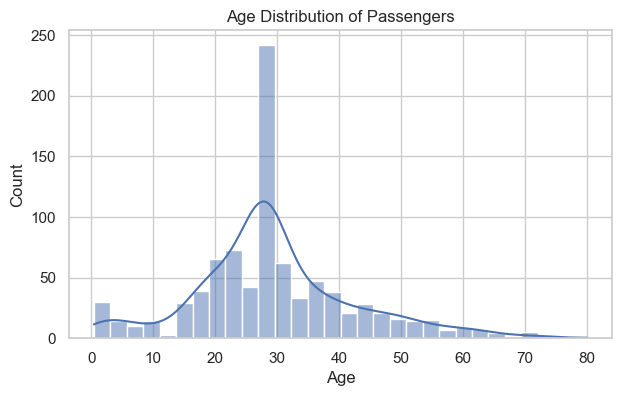

In [7]:
plt.figure(figsize=(7,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Insight:**  
Most passengers were young adults between 20 and 40 years of age.  
Very few passengers were elderly, indicating limited senior presence on the ship.

### Bar Chart – Survival Rate by Gender

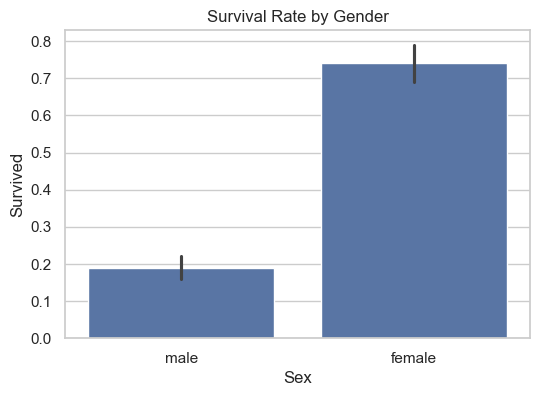

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

**Insight:**  
Female passengers had a significantly higher survival rate than males.  
This highlights the impact of evacuation priority given to women.

### Boxplot – Fare by Passenger Class

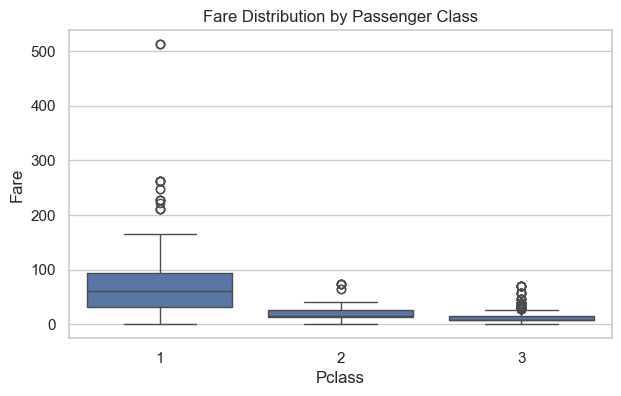

In [9]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare Distribution by Passenger Class")
plt.show()

**Insight:**  
First-class passengers paid substantially higher fares compared to lower classes.  
This shows clear socio-economic differences among passengers.

### Scatter Plot – Age vs Fare (Survival Colored)

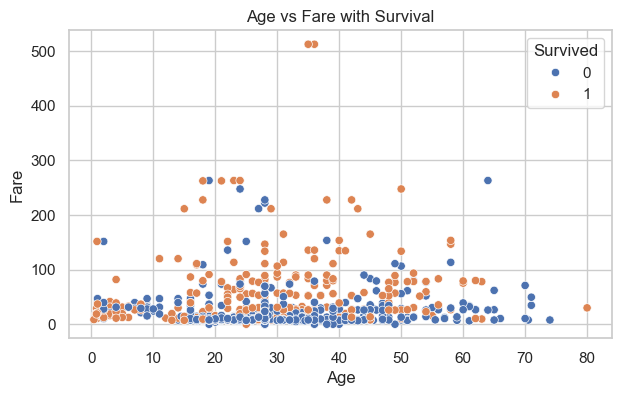

In [10]:
plt.figure(figsize=(7,4))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare with Survival")
plt.show()

**Insight:**  
Passengers who paid higher fares had better chances of survival.  
Survival appears more strongly related to fare than to age.

### Heatmap – Correlation Matrix

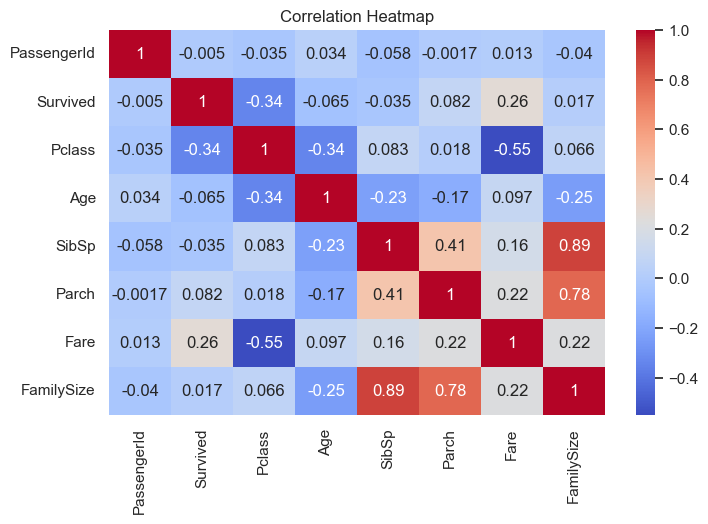

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Insight:**  
Fare shows a positive correlation with survival probability.  
Passenger class is negatively correlated with survival, indicating higher risk for lower classes.

### Facet Grid Analysis
Survival by Passenger Class & Gender

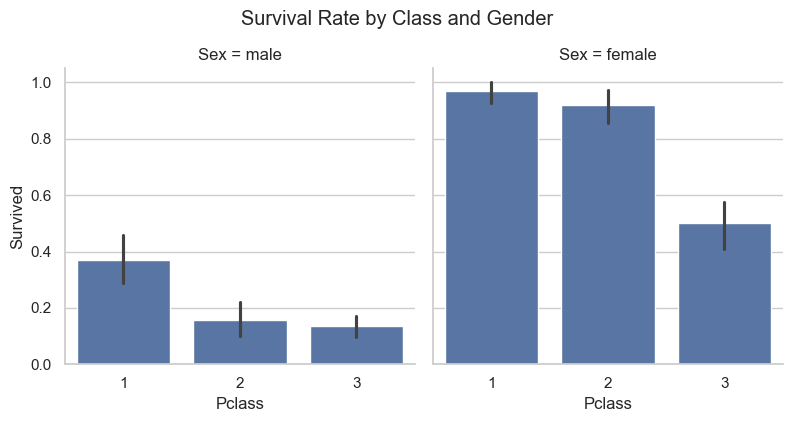

In [12]:
sns.catplot(
    col="Sex",
    x="Pclass",
    y="Survived",
    kind="bar",
    data=df,
    height=4,
    aspect=1
)
plt.suptitle("Survival Rate by Class and Gender", y=1.05)
plt.show()

**Insight:**  
Females had consistently higher survival rates across all passenger classes.  
Male survival dropped sharply in third class, indicating class-based vulnerability.

### Conclusion
The analysis shows that gender, passenger class, and fare played major roles in survival.
Women and higher-class passengers had significantly better chances of survival.
Effective visualization helps clearly communicate these patterns.